# Imbalanced datasets (Updated: K = 1, 3, 10)

This notebook follows the practical session instructions from the official TP3 document
(see the PDF shared in class) and includes an additional requirement stated by the instructor:
for each dataset we generate exactly **one balanced dataset (K=1)** and **two imbalanced datasets (K=3, K=10)**.

For each dataset, we generate:
- K = 1 (balanced)
- K = 3 (imbalanced)
- K = 10 (highly imbalanced)

Then we:
- Train a vanilla classifier (SVC)
- Train an advanced classifier (Random Forest)
- Split data with 40% test
- Report accuracy and balanced accuracy (+ F1 for minority class)
- Apply oversampling and undersampling
- Use class-weighted (biased) classifiers

## Q1. Generating imbalanced datasets

We generate **two 2D binary datasets** with **N = 300** samples each:
1. `make_moons` (non-linear)
2. `make_classification` (generic)

For each dataset, we generate **three class-balance settings**:
- K=1 (balanced: 50/50)
- K=3 (majority has 3× more samples than minority)
- K=10 (majority has 10× more samples than minority)

We visualize the datasets for each K.

In [1]:
# Imports + helpers
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_classification
from sklearn.utils import resample

SEED = 42
N = 300
Ks = [1, 3, 10]  # Instructor requirement

def class_sizes_from_K(N, K):
    """
    K = majority/minority ratio.
    For N=300:
      K=1  -> 150/150
      K=3  -> 225/75
      K=10 -> ~273/27
    """
    maj = int(round(N * (K / (K + 1))))
    mino = N - maj
    return maj, mino

def plot_dataset(ax, X, y, title=""):
    ax.scatter(X[y==0, 0], X[y==0, 1], s=20, alpha=0.8, label="Class 0 (majority)")
    ax.scatter(X[y==1, 0], X[y==1, 1], s=20, alpha=0.8, label="Class 1 (minority)")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=8)

def print_counts(name, K, y):
    c0, c1 = np.bincount(y)
    print(f"{name:12s} K={K:<2d} -> class0={c0:3d}, class1={c1:3d}, ratio={c0/max(c1,1):.2f}")

In [2]:
# Generate datasets (moons + classification) for K=1,3,10
datasets = {}  # key: (dataset_name, K) -> (X, y)

# Dataset 1: make_moons
# make_moons has no "weights", so we generate a big pool and then subsample to enforce exact K
X_pool, y_pool = make_moons(n_samples=3000, noise=0.25, random_state=SEED)

X0_all = X_pool[y_pool==0]
X1_all = X_pool[y_pool==1]

for K in Ks:
    maj_n, min_n = class_sizes_from_K(N, K)

    X0 = resample(X0_all, replace=False, n_samples=maj_n, random_state=SEED)
    X1 = resample(X1_all, replace=False, n_samples=min_n, random_state=SEED+1)

    y0 = np.zeros(len(X0), dtype=int)
    y1 = np.ones(len(X1), dtype=int)

    X = np.vstack([X0, X1])
    y = np.hstack([y0, y1])

    rng = np.random.default_rng(SEED)
    idx = rng.permutation(len(y))
    X, y = X[idx], y[idx]

    datasets[("moons", K)] = (X, y)
    print_counts("moons", K, y)

# Dataset 2: make_classification
for K in Ks:
    maj_n, min_n = class_sizes_from_K(N, K)
    w_major = maj_n / N
    w_minor = min_n / N

    X, y = make_classification(
        n_samples=N,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        n_clusters_per_class=1,
        class_sep=1.1,
        weights=[w_major, w_minor],  # controls K
        flip_y=0.04,
        random_state=SEED
    )

    datasets[("classif", K)] = (X, y)
    print_counts("classif", K, y)

moons        K=1  -> class0=150, class1=150, ratio=1.00
moons        K=3  -> class0=225, class1= 75, ratio=3.00
moons        K=10 -> class0=273, class1= 27, ratio=10.11
classif      K=1  -> class0=150, class1=150, ratio=1.00
classif      K=3  -> class0=222, class1= 78, ratio=2.85
classif      K=10 -> class0=265, class1= 35, ratio=7.57


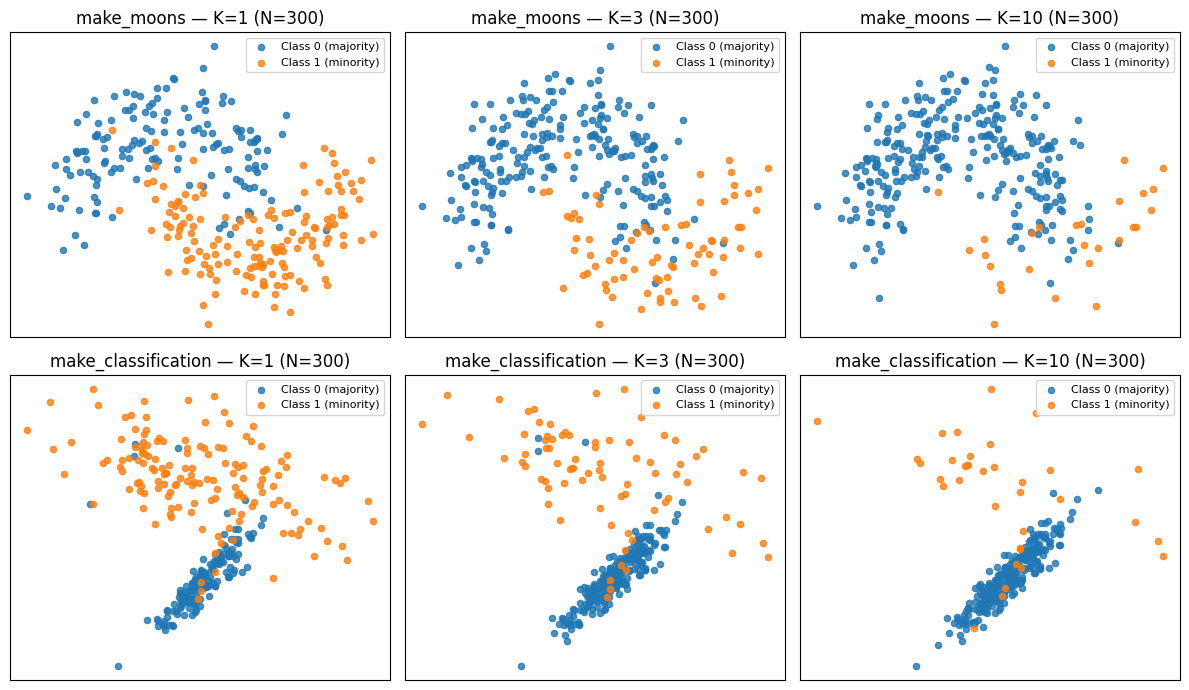

In [3]:
# Visualize datasets (2 rows × 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for j, K in enumerate(Ks):
    X, y = datasets[("moons", K)]
    plot_dataset(axes[0, j], X, y, title=f"make_moons — K={K} (N={N})")

    X, y = datasets[("classif", K)]
    plot_dataset(axes[1, j], X, y, title=f"make_classification — K={K} (N={N})")

plt.tight_layout()
plt.show()

## Q2. Set classifiers

We choose:
- Vanilla classifier: **SVC** (RBF kernel)
- Advanced classifier: **Random Forest**

We split each dataset into:
- 60% train
- 40% test (required)

We report:
- Accuracy (required)
- Balanced Accuracy (required, better for imbalance)
- F1-score for the minority class (extra metric)

In [4]:
# Imports for Q2 + helpers
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

def decision_boundary(ax, clf, X, y, title=""):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X[y==0, 0], X[y==0, 1], s=18, alpha=0.8, label="Class 0")
    ax.scatter(X[y==1, 0], X[y==1, 1], s=18, alpha=0.8, label="Class 1")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=8)

def evaluate_model(name, clf, X_train, X_test, y_train, y_test):
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc  = accuracy_score(y_test, pred)
    bacc = balanced_accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred)  # minority is label 1

    print(f"\n=== {name} ===")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Balanced Accuracy : {bacc:.4f}")
    print(f"F1 (minority=1)   : {f1:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))
    print("\nClassification report:\n", classification_report(y_test, pred, digits=4))

    return {"acc": acc, "bacc": bacc, "f1": f1}


=== moons K=1 | SVC ===
Accuracy          : 0.9333
Balanced Accuracy : 0.9333
F1 (minority=1)   : 0.9355
Confusion matrix:
 [[54  6]
 [ 2 58]]

Classification report:
               precision    recall  f1-score   support

           0     0.9643    0.9000    0.9310        60
           1     0.9062    0.9667    0.9355        60

    accuracy                         0.9333       120
   macro avg     0.9353    0.9333    0.9333       120
weighted avg     0.9353    0.9333    0.9333       120


=== moons K=1 | RF ===
Accuracy          : 0.9167
Balanced Accuracy : 0.9167
F1 (minority=1)   : 0.9180
Confusion matrix:
 [[54  6]
 [ 4 56]]

Classification report:
               precision    recall  f1-score   support

           0     0.9310    0.9000    0.9153        60
           1     0.9032    0.9333    0.9180        60

    accuracy                         0.9167       120
   macro avg     0.9171    0.9167    0.9166       120
weighted avg     0.9171    0.9167    0.9166       120



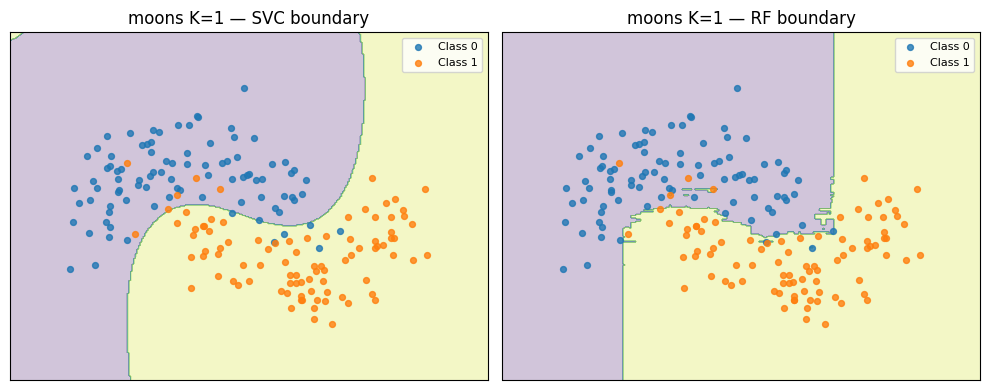


=== moons K=3 | SVC ===
Accuracy          : 0.9417
Balanced Accuracy : 0.9167
F1 (minority=1)   : 0.8814
Confusion matrix:
 [[87  3]
 [ 4 26]]

Classification report:
               precision    recall  f1-score   support

           0     0.9560    0.9667    0.9613        90
           1     0.8966    0.8667    0.8814        30

    accuracy                         0.9417       120
   macro avg     0.9263    0.9167    0.9213       120
weighted avg     0.9412    0.9417    0.9413       120


=== moons K=3 | RF ===
Accuracy          : 0.9417
Balanced Accuracy : 0.9167
F1 (minority=1)   : 0.8814
Confusion matrix:
 [[87  3]
 [ 4 26]]

Classification report:
               precision    recall  f1-score   support

           0     0.9560    0.9667    0.9613        90
           1     0.8966    0.8667    0.8814        30

    accuracy                         0.9417       120
   macro avg     0.9263    0.9167    0.9213       120
weighted avg     0.9412    0.9417    0.9413       120



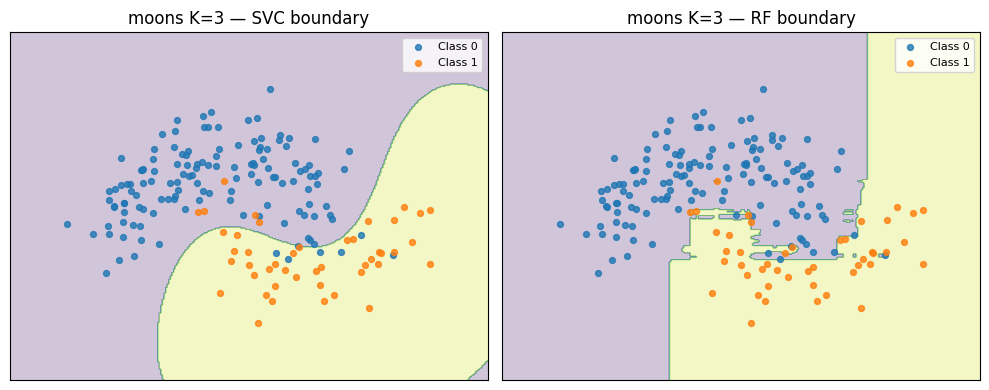


=== moons K=10 | SVC ===
Accuracy          : 0.9667
Balanced Accuracy : 0.8182
F1 (minority=1)   : 0.7778
Confusion matrix:
 [[109   0]
 [  4   7]]

Classification report:
               precision    recall  f1-score   support

           0     0.9646    1.0000    0.9820       109
           1     1.0000    0.6364    0.7778        11

    accuracy                         0.9667       120
   macro avg     0.9823    0.8182    0.8799       120
weighted avg     0.9678    0.9667    0.9633       120


=== moons K=10 | RF ===
Accuracy          : 0.9500
Balanced Accuracy : 0.8090
F1 (minority=1)   : 0.7000
Confusion matrix:
 [[107   2]
 [  4   7]]

Classification report:
               precision    recall  f1-score   support

           0     0.9640    0.9817    0.9727       109
           1     0.7778    0.6364    0.7000        11

    accuracy                         0.9500       120
   macro avg     0.8709    0.8090    0.8364       120
weighted avg     0.9469    0.9500    0.9477       120


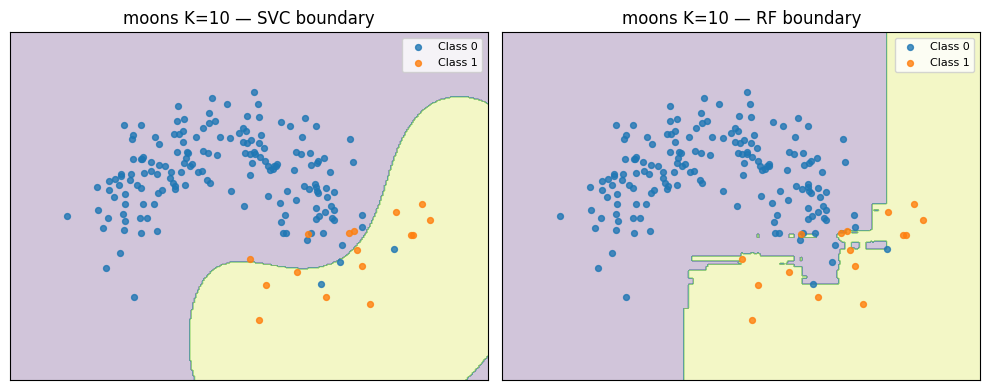


=== classif K=1 | SVC ===
Accuracy          : 0.9000
Balanced Accuracy : 0.9000
F1 (minority=1)   : 0.9016
Confusion matrix:
 [[53  7]
 [ 5 55]]

Classification report:
               precision    recall  f1-score   support

           0     0.9138    0.8833    0.8983        60
           1     0.8871    0.9167    0.9016        60

    accuracy                         0.9000       120
   macro avg     0.9004    0.9000    0.9000       120
weighted avg     0.9004    0.9000    0.9000       120


=== classif K=1 | RF ===
Accuracy          : 0.9000
Balanced Accuracy : 0.9000
F1 (minority=1)   : 0.9016
Confusion matrix:
 [[53  7]
 [ 5 55]]

Classification report:
               precision    recall  f1-score   support

           0     0.9138    0.8833    0.8983        60
           1     0.8871    0.9167    0.9016        60

    accuracy                         0.9000       120
   macro avg     0.9004    0.9000    0.9000       120
weighted avg     0.9004    0.9000    0.9000       120



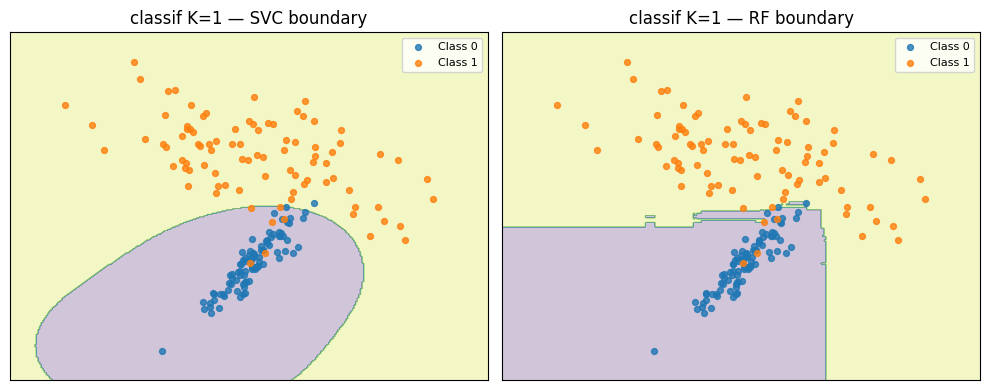


=== classif K=3 | SVC ===
Accuracy          : 0.9333
Balanced Accuracy : 0.9025
F1 (minority=1)   : 0.8667
Confusion matrix:
 [[86  3]
 [ 5 26]]

Classification report:
               precision    recall  f1-score   support

           0     0.9451    0.9663    0.9556        89
           1     0.8966    0.8387    0.8667        31

    accuracy                         0.9333       120
   macro avg     0.9208    0.9025    0.9111       120
weighted avg     0.9325    0.9333    0.9326       120


=== classif K=3 | RF ===
Accuracy          : 0.9250
Balanced Accuracy : 0.8969
F1 (minority=1)   : 0.8525
Confusion matrix:
 [[85  4]
 [ 5 26]]

Classification report:
               precision    recall  f1-score   support

           0     0.9444    0.9551    0.9497        89
           1     0.8667    0.8387    0.8525        31

    accuracy                         0.9250       120
   macro avg     0.9056    0.8969    0.9011       120
weighted avg     0.9244    0.9250    0.9246       120



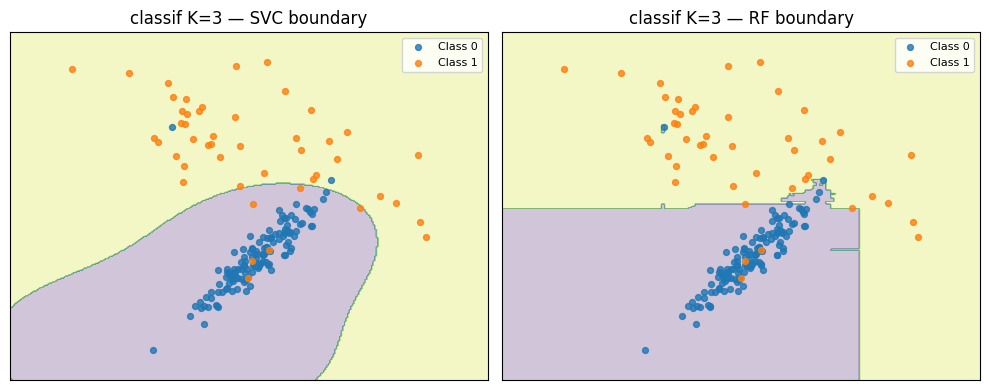


=== classif K=10 | SVC ===
Accuracy          : 0.9583
Balanced Accuracy : 0.8214
F1 (minority=1)   : 0.7826
Confusion matrix:
 [[106   0]
 [  5   9]]

Classification report:
               precision    recall  f1-score   support

           0     0.9550    1.0000    0.9770       106
           1     1.0000    0.6429    0.7826        14

    accuracy                         0.9583       120
   macro avg     0.9775    0.8214    0.8798       120
weighted avg     0.9602    0.9583    0.9543       120


=== classif K=10 | RF ===
Accuracy          : 0.9500
Balanced Accuracy : 0.8167
F1 (minority=1)   : 0.7500
Confusion matrix:
 [[105   1]
 [  5   9]]

Classification report:
               precision    recall  f1-score   support

           0     0.9545    0.9906    0.9722       106
           1     0.9000    0.6429    0.7500        14

    accuracy                         0.9500       120
   macro avg     0.9273    0.8167    0.8611       120
weighted avg     0.9482    0.9500    0.9463       

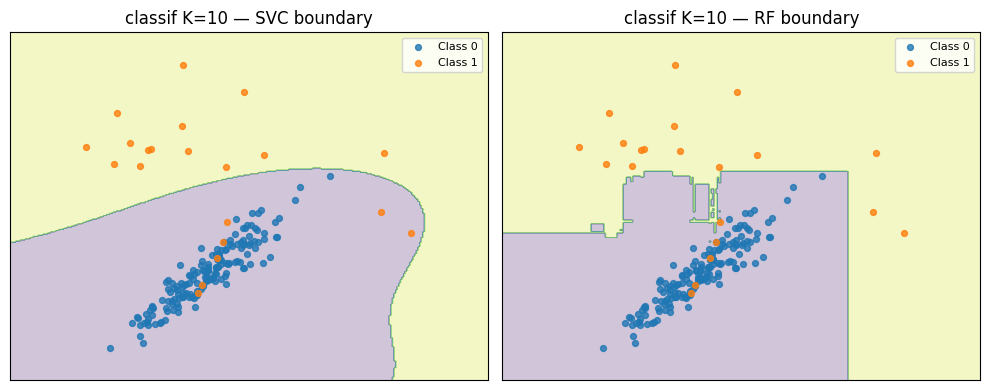

In [5]:
# Run Q2 for all datasets (K=1,3,10)
svc = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)
rf  = RandomForestClassifier(n_estimators=300, random_state=SEED)

results_q2 = {}

for (dname, K), (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.40, random_state=SEED, stratify=y
    )

    r1 = evaluate_model(f"{dname} K={K} | SVC", svc, X_train, X_test, y_train, y_test)
    r2 = evaluate_model(f"{dname} K={K} | RF", rf, X_train, X_test, y_train, y_test)

    results_q2[(dname, K, "SVC")] = r1
    results_q2[(dname, K, "RF")]  = r2

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    svc.fit(X_train, y_train)
    decision_boundary(ax[0], svc, X_train, y_train, title=f"{dname} K={K} — SVC boundary")

    rf.fit(X_train, y_train)
    decision_boundary(ax[1], rf, X_train, y_train, title=f"{dname} K={K} — RF boundary")

    plt.tight_layout()
    plt.show()

### Q2 Interpretation

- For **K=1**, accuracy and balanced accuracy are usually similar.
- For **K=10**, accuracy can stay high even if the minority class is misclassified.
  Balanced accuracy and minority F1 highlight minority performance.
- SVC tends to learn smooth non-linear boundaries; Random Forest produces piecewise regions.

## Q3. Oversampling

We oversample the **minority class** in the training set by sampling with replacement
until both classes have the same size.

Benefits:
- Improves minority recall/F1 without removing data.

Limitations:
- Duplicates minority points → risk of overfitting.

In [13]:
# Oversampling + evaluation (run for K=3 and K=10)
def random_oversample(X, y, minority_label=1, random_state=SEED):
    Xmaj = X[y != minority_label]
    ymaj = y[y != minority_label]
    Xmin = X[y == minority_label]
    ymin = y[y == minority_label]

    Xmin_up, ymin_up = resample(
        Xmin, ymin,
        replace=True,
        n_samples=len(Xmaj),
        random_state=random_state
    )

    X_new = np.vstack([Xmaj, Xmin_up])
    y_new = np.hstack([ymaj, ymin_up])

    rng = np.random.default_rng(random_state)
    idx = rng.permutation(len(y_new))
    return X_new[idx], y_new[idx]

for dname in ["moons", "classif"]:
    for K in [3, 10]:
        X, y = datasets[(dname, K)]
        print("\n" + "="*80)
        print(f"Q3 Oversampling — {dname}, K={K}")
        print(len(y[y==0]), "majority samples,", len(y[y==1]), "samples before oversampling.")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.40, random_state=SEED, stratify=y
        )

        X_train_os, y_train_os = random_oversample(X_train, y_train)
        print(len(y_train_os[y_train_os==0]), "majority samples,", len(y_train_os[y_train_os==1]), "samples after oversampling.")

        evaluate_model(f"{dname} K={K} | SVC oversample",
                       SVC(kernel="rbf", gamma="scale", random_state=SEED),
                       X_train_os, X_test, y_train_os, y_test)

        evaluate_model(f"{dname} K={K} | RF oversample",
                       RandomForestClassifier(n_estimators=300, random_state=SEED),
                       X_train_os, X_test, y_train_os, y_test)


Q3 Oversampling — moons, K=3
225 majority samples, 75 samples before oversampling.
135 majority samples, 135 samples after oversampling.

=== moons K=3 | SVC oversample ===
Accuracy          : 0.9583
Balanced Accuracy : 0.9722
F1 (minority=1)   : 0.9231
Confusion matrix:
 [[85  5]
 [ 0 30]]

Classification report:
               precision    recall  f1-score   support

           0     1.0000    0.9444    0.9714        90
           1     0.8571    1.0000    0.9231        30

    accuracy                         0.9583       120
   macro avg     0.9286    0.9722    0.9473       120
weighted avg     0.9643    0.9583    0.9593       120


=== moons K=3 | RF oversample ===
Accuracy          : 0.9167
Balanced Accuracy : 0.8667
F1 (minority=1)   : 0.8214
Confusion matrix:
 [[87  3]
 [ 7 23]]

Classification report:
               precision    recall  f1-score   support

           0     0.9255    0.9667    0.9457        90
           1     0.8846    0.7667    0.8214        30

    accuracy

## Q4. Undersampling

We undersample the **majority class** in the training set so that both classes
have the same size.

Benefits:
- Faster training and reduces majority dominance.

Limitations:
- Discards majority data → may lose information and reduce accuracy.

In [ ]:
# Undersampling + evaluation
def random_undersample(X, y, majority_label=0, random_state=SEED):
    Xmaj = X[y == majority_label]
    ymaj = y[y == majority_label]
    Xmin = X[y != majority_label]
    ymin = y[y != majority_label]

    Xmaj_down, ymaj_down = resample(
        Xmaj, ymaj,
        replace=False,
        n_samples=len(Xmin),
        random_state=random_state
    )

    X_new = np.vstack([Xmaj_down, Xmin])
    y_new = np.hstack([ymaj_down, ymin])

    rng = np.random.default_rng(random_state)
    idx = rng.permutation(len(y_new))
    return X_new[idx], y_new[idx]

for dname in ["moons", "classif"]:
    for K in [3, 10]:
        X, y = datasets[(dname, K)]
        print("\n" + "="*80)
        print(f"Q4 Undersampling — {dname}, K={K}")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.40, random_state=SEED, stratify=y
        )

        X_train_us, y_train_us = random_undersample(X_train, y_train)
        print(len(y[y==0]), "majority samples,", len(y[y==1]), "samples before undersampling.")
        print(len(y_train_us[y_train_us==0]), "majority samples,", len(y_train_us[y_train_us==1]), "samples after undersampling.")

        evaluate_model(f"{dname} K={K} | SVC undersample",
                       SVC(kernel="rbf", gamma="scale", random_state=SEED),
                       X_train_us, X_test, y_train_us, y_test)

        evaluate_model(f"{dname} K={K} | RF undersample",
                       RandomForestClassifier(n_estimators=300, random_state=SEED),
                       X_train_us, X_test, y_train_us, y_test)


Q4 Undersampling — moons, K=3
225 majority samples, 75 minority samples after undersampling.
45 majority samples, 45 minority samples after undersampling.

=== moons K=3 | SVC undersample ===
Accuracy          : 0.9417
Balanced Accuracy : 0.9611
F1 (minority=1)   : 0.8955
Confusion matrix:
 [[83  7]
 [ 0 30]]

Classification report:
               precision    recall  f1-score   support

           0     1.0000    0.9222    0.9595        90
           1     0.8108    1.0000    0.8955        30

    accuracy                         0.9417       120
   macro avg     0.9054    0.9611    0.9275       120
weighted avg     0.9527    0.9417    0.9435       120


=== moons K=3 | RF undersample ===
Accuracy          : 0.8917
Balanced Accuracy : 0.8611
F1 (minority=1)   : 0.7869
Confusion matrix:
 [[83  7]
 [ 6 24]]

Classification report:
               precision    recall  f1-score   support

           0     0.9326    0.9222    0.9274        90
           1     0.7742    0.8000    0.7869    

## Q5. Biased classifiers (cost-sensitive learning)

Instead of changing the dataset, we change the classifier to penalize minority errors more.

We use:
- `class_weight="balanced"` for SVC and Random Forest

Expected outcome:
- Balanced accuracy and minority F1 often increase,
  sometimes with a small decrease in overall accuracy.

In [8]:
# Compare plain vs weighted (K=3,10)
for dname in ["moons", "classif"]:
    for K in [3, 10]:
        X, y = datasets[(dname, K)]
        print("\n" + "="*80)
        print(f"Q5 Class weights — {dname}, K={K}")

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.40, random_state=SEED, stratify=y
        )

        # SVC
        evaluate_model(f"{dname} K={K} | SVC plain",
                       SVC(kernel="rbf", gamma="scale", random_state=SEED),
                       X_train, X_test, y_train, y_test)

        evaluate_model(f"{dname} K={K} | SVC weighted",
                       SVC(kernel="rbf", gamma="scale", class_weight="balanced", random_state=SEED),
                       X_train, X_test, y_train, y_test)

        # Random Forest
        evaluate_model(f"{dname} K={K} | RF plain",
                       RandomForestClassifier(n_estimators=300, random_state=SEED),
                       X_train, X_test, y_train, y_test)

        evaluate_model(f"{dname} K={K} | RF weighted",
                       RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED),
                       X_train, X_test, y_train, y_test)


Q5 Class weights — moons, K=3

=== moons K=3 | SVC plain ===
Accuracy          : 0.9417
Balanced Accuracy : 0.9167
F1 (minority=1)   : 0.8814
Confusion matrix:
 [[87  3]
 [ 4 26]]

Classification report:
               precision    recall  f1-score   support

           0     0.9560    0.9667    0.9613        90
           1     0.8966    0.8667    0.8814        30

    accuracy                         0.9417       120
   macro avg     0.9263    0.9167    0.9213       120
weighted avg     0.9412    0.9417    0.9413       120


=== moons K=3 | SVC weighted ===
Accuracy          : 0.9500
Balanced Accuracy : 0.9667
F1 (minority=1)   : 0.9091
Confusion matrix:
 [[84  6]
 [ 0 30]]

Classification report:
               precision    recall  f1-score   support

           0     1.0000    0.9333    0.9655        90
           1     0.8333    1.0000    0.9091        30

    accuracy                         0.9500       120
   macro avg     0.9167    0.9667    0.9373       120
weighted avg     

## Conclusion

- Accuracy alone can be misleading on imbalanced datasets (especially for K=10).
- Balanced accuracy and minority F1 better reflect performance on both classes.
- Oversampling improves minority performance but may overfit due to duplicates.
- Undersampling reduces majority dominance but may lose information.
- Class-weighted learning is often a strong baseline because it keeps all data while handling imbalance in the objective.